In [1]:
import torch
import torchvision
from transformers import AutoModelForImageClassification

from devinterp.optim import SGLD
from devinterp.slt.sampler import estimate_learning_coeff_with_summary
from devinterp.vis_utils import EpsilonBetaAnalyzer

# Local import:
# import sys
# sys.path.append("../src/devinterp")
# from vis_utils import EpsilonBetaAnalyzer


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def evaluate(model, data):
    inputs, outputs = data

    return torch.nn.functional.cross_entropy(model(inputs).logits, outputs), {
        "outputs": outputs
    }


# Load a pretrained MNIST classifier
model = AutoModelForImageClassification.from_pretrained("fxmarty/resnet-tiny-mnist")

model.to(DEVICE)

data = torchvision.datasets.MNIST(
    root="../data",
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

batch_size = 256

loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)

/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from palamedes.sgld_sampler import *


params = SGLDParams(
    eps=0.00019306977288832496,  # total step size
    gamma=100,  # localization term
    batch_size=batch_size,  # batch size
    nbeta=64.,  # this is not beta, but beta * n, where n= |whole dataset|
    num_steps=300,  # number of steps
    checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
    save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
    # device=device,
    preconditioner="none",  # "none" or "rmsprop
    alpha_rmsprop=0.99,  # rmsprop parameter
    lambda_rmsprop=1e-5,  # rmsprop parameter
)

sgld_dict = sgld(
    model,
    params,
    dataset=loader,
    cost_fn="cross_entropy",
    device=DEVICE,
    fp16=False,
)

4.525596618652344
7.649840354919434
9.840354919433594
3.8541224002838135
3.416557550430298
3.5116384029388428
2.5994341373443604
2.873680830001831
4.1671857833862305
2.674252986907959
2.5271859169006348
2.137099504470825
2.262758255004883
2.44285249710083
2.808753490447998
3.000948905944824
2.8171374797821045
2.5137152671813965
2.5308761596679688
2.948549509048462
2.539642810821533
2.606682538986206
2.753284454345703
2.4423611164093018
2.2461726665496826
2.222956657409668
2.457773447036743
2.938735008239746
3.1397898197174072
3.089632749557495
2.5488643646240234
2.293330192565918
2.179800033569336
2.417393207550049
2.3647983074188232
2.413398504257202
2.5036892890930176
4.476528644561768
3.6565017700195312
3.5500617027282715
2.5925731658935547
2.5744404792785645
3.020814895629883
2.8939905166625977
2.7702910900115967
2.3009278774261475
2.452162742614746
2.271106719970703
2.6553702354431152
3.0817174911499023
5.008638858795166
5.606507301330566
7.104946136474609
4.013066291809082
3.9298

In [3]:
sgld_dict['loss'][-1]

2.5099358558654785

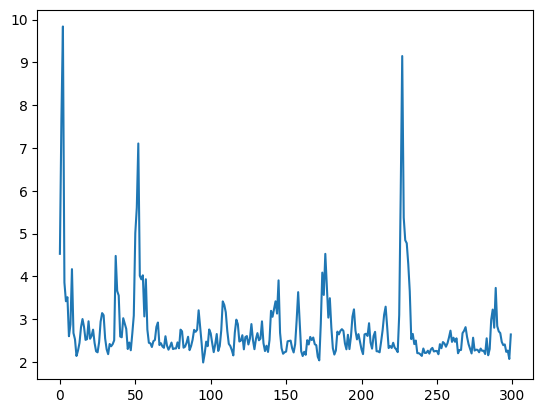

In [7]:
import matplotlib.pyplot as plt
plt.plot(sgld_dict['loss'])
